In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

In [3]:
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"

residue_path = PROCESSED_DIR / "chi1_residue_level_dataset_with_backbone.csv"

residue_df = pd.read_csv(residue_path)

residue_df.head()

/var/folders/j3/qr5mg5rj55j5lf7yh978r__80000gn/T/ipykernel_1390/2338238424.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  residue_df = pd.read_csv(residue_path)


,pdb_id,chain_id,residue_number,insertion_code,resname,chi1_angle,chi1_bin_10deg,target_mask,phi_angle,psi_angle,...,ca_y,ca_z,has_ca,polarity_group,hydropathy_group,volume_group,chemical_group,physicochemical_group,charge_group,hydrogen_donor_acceptor_group
0,2BO5,A,1,NaN,PHE,267.667646,26,1,NaN,181.918425,...,12.444,24.544001,1,nonpolar,hydrophobic,large,aromatic,aromatic,neutral,none
1,2BO5,A,2,NaN,ALA,NaN,-100,0,60.562806,33.116558,...,11.484,21.757999,1,nonpolar,hydrophobic,small,aliphatic,nonpolar_aliphatic,neutral,none
2,2BO5,A,3,NaN,LYS,270.463347,27,1,299.348529,285.420907,...,9.539,24.302000,1,polar,hydrophilic,large,basic,positive,positive,donor
3,2BO5,A,4,NaN,LEU,314.589093,31,1,61.046673,156.017583,...,9.970,22.927000,1,nonpolar,hydrophobic,large,aliphatic,nonpolar_aliphatic,neutral,none
4,2BO5,A,5,NaN,VAL,286.087049,28,1,248.450014,326.412570,...,7.605,23.750000,1,nonpolar,hydrophobic,medium,aliphatic,nonpolar_aliphatic,neutral,none


In [5]:

residue_path = PROCESSED_DIR / "chi1_residue_level_dataset_with_backbone.csv"

residue_df = pd.read_csv(residue_path)

SPLIT_DIR = DATA_DIR / "splits"

train_pdb_ids = set(pd.read_csv(SPLIT_DIR / "train_pdb_ids.csv")["pdb_id"])
val_pdb_ids = set(pd.read_csv(SPLIT_DIR / "val_pdb_ids.csv")["pdb_id"])
test_pdb_ids = set(pd.read_csv(SPLIT_DIR / "test_pdb_ids.csv")["pdb_id"])

train_residue_df = residue_df[residue_df["pdb_id"].isin(train_pdb_ids)].copy()
val_residue_df = residue_df[residue_df["pdb_id"].isin(val_pdb_ids)].copy()
test_residue_df = residue_df[residue_df["pdb_id"].isin(test_pdb_ids)].copy()

print(train_residue_df.shape)
print(val_residue_df.shape)
print(test_residue_df.shape)

/var/folders/j3/qr5mg5rj55j5lf7yh978r__80000gn/T/ipykernel_1390/601228350.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  residue_df = pd.read_csv(residue_path)


(929004, 27)
(113997, 27)
(118229, 27)


In [6]:
ID_COLUMNS = [
    "pdb_id",
    "chain_id",
    "residue_number",
    "insertion_code",
]

FEATURE_COLUMNS = [
    "resname",
    "polarity_group",
    "hydropathy_group",
    "volume_group",
    "chemical_group",
    "physicochemical_group",
    "charge_group",
    "hydrogen_donor_acceptor_group",
]

TARGET_COLUMN = "chi1_bin_10deg"
MASK_COLUMN = "target_mask"

WINDOW_SIZE = 65
CONTEXT_RADIUS = WINDOW_SIZE // 2

PAD_TOKEN = "PAD"
IGNORE_INDEX = -100

NUMERIC_FEATURE_COLUMNS = [
    "phi_sin",
    "phi_cos",
    "psi_sin",
    "psi_cos",
    "has_phi",
    "has_psi",
    "relative_position",
]

DISTANCE_NORMALIZATION = 30.0

In [7]:
def prepare_residue_df_for_windows(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["pdb_id"] = df["pdb_id"].astype(str).str.upper()
    df["chain_id"] = df["chain_id"].astype(str)

    df["residue_number"] = df["residue_number"].astype(int)

    df["insertion_code"] = (
        df["insertion_code"]
        .fillna("")
        .astype(str)
        .replace("nan", "")
    )

    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)
    df[MASK_COLUMN] = df[MASK_COLUMN].astype(int)

    df = df.sort_values(
        ["pdb_id", "chain_id", "residue_number", "insertion_code"]
    ).reset_index(drop=True)

    return df

In [8]:
residue_df = prepare_residue_df_for_windows(residue_df)

residue_df.head()

,pdb_id,chain_id,residue_number,insertion_code,resname,chi1_angle,chi1_bin_10deg,target_mask,phi_angle,psi_angle,...,ca_y,ca_z,has_ca,polarity_group,hydropathy_group,volume_group,chemical_group,physicochemical_group,charge_group,hydrogen_donor_acceptor_group
0,133L,A,1,,LYS,72.602035,7,1,NaN,151.664947,...,20.433001,21.160000,1,polar,hydrophilic,large,basic,positive,positive,donor
1,133L,A,2,,VAL,184.764731,18,1,254.529890,114.762469,...,19.736000,18.659000,1,nonpolar,hydrophobic,medium,aliphatic,nonpolar_aliphatic,neutral,none
2,133L,A,3,,PHE,279.004006,27,1,286.350988,150.684206,...,22.340000,18.976999,1,nonpolar,hydrophobic,large,aromatic,aromatic,neutral,none
3,133L,A,4,,GLU,284.236970,28,1,273.982337,158.728892,...,23.539000,16.051001,1,polar,hydrophilic,large,acidic,negative,negative,acceptor
4,133L,A,5,,ARG,188.255005,18,1,305.536639,301.401648,...,23.135000,16.552000,1,polar,hydrophilic,large,basic,positive,positive,donor


In [9]:
residue_df[
    [
        "resname",
        "chi1_bin_10deg",
        "target_mask",
        "phi_sin",
        "phi_cos",
        "psi_sin",
        "psi_cos",
        "has_phi",
        "has_psi",
        "ca_x",
        "ca_y",
        "ca_z",
        "has_ca",
    ]
].head()

,resname,chi1_bin_10deg,target_mask,phi_sin,phi_cos,psi_sin,psi_cos,has_phi,has_psi,ca_x,ca_y,ca_z,has_ca
0,LYS,7,1,0.000000,0.000000,0.474627,-0.880187,0,1,1.782,20.433001,21.160000,1
1,VAL,18,1,-0.963770,-0.266736,0.908052,-0.418857,1,1,4.609,19.736000,18.659000,1
2,PHE,27,1,-0.959555,0.281521,0.489623,-0.871934,1,1,7.321,22.340000,18.976999,1
3,GLU,28,1,-0.997586,0.069449,0.362781,-0.931874,1,1,9.297,23.539000,16.051001,1
4,ARG,18,1,-0.813744,0.581223,-0.853536,0.521034,1,1,13.067,23.135000,16.552000,1


In [ ]:
# def make_pad_residue():
#     row = {}

#     for col in FEATURE_COLUMNS:
#         row[col] = PAD_TOKEN

#     row["phi_sin"] = 0.0
#     row["phi_cos"] = 0.0
#     row["psi_sin"] = 0.0
#     row["psi_cos"] = 0.0
#     row["has_phi"] = 0
#     row["has_psi"] = 0

#     row["ca_x"] = np.nan
#     row["ca_y"] = np.nan
#     row["ca_z"] = np.nan
#     row["has_ca"] = 0

#     row[TARGET_COLUMN] = IGNORE_INDEX
#     row[MASK_COLUMN] = 0

#     row["residue_number"] = np.nan
#     row["insertion_code"] = ""
#     row["is_padding"] = 1

#     return row

In [ ]:
# def compute_ca_distance_matrix(ca_coords, has_ca_mask):
#     ca_coords = np.asarray(ca_coords, dtype=np.float32)
#     has_ca_mask = np.asarray(has_ca_mask, dtype=bool)

#     window_size = ca_coords.shape[0]

#     distance_matrix = np.zeros((window_size, window_size), dtype=np.float32)

#     for i in range(window_size):
#         for j in range(window_size):
#             if has_ca_mask[i] and has_ca_mask[j]:
#                 distance = np.linalg.norm(ca_coords[i] - ca_coords[j])
#                 distance = min(distance / DISTANCE_NORMALIZATION, 1.0)
#                 distance_matrix[i, j] = distance
#             else:
#                 distance_matrix[i, j] = 1.0

#     return distance_matrix

In [ ]:
# def build_window_for_chain_position(chain_df: pd.DataFrame, center_idx: int):
#     n = len(chain_df)

#     features = []
#     numeric_features = []

#     targets = []
#     target_mask = []

#     window_residue_numbers = []
#     window_insertion_codes = []
#     window_resnames = []
#     padding_mask = []

#     ca_coords = []
#     has_ca_mask = []

#     for pos in range(center_idx - CONTEXT_RADIUS, center_idx + CONTEXT_RADIUS + 1):
#         relative_position = (pos - center_idx) / CONTEXT_RADIUS

#         if 0 <= pos < n:
#             row = chain_df.iloc[pos]

#             features.append({
#                 col: row[col]
#                 for col in FEATURE_COLUMNS
#             })

#             numeric_features.append([
#                 float(row["phi_sin"]),
#                 float(row["phi_cos"]),
#                 float(row["psi_sin"]),
#                 float(row["psi_cos"]),
#                 float(row["has_phi"]),
#                 float(row["has_psi"]),
#                 float(relative_position),
#             ])

#             targets.append(int(row[TARGET_COLUMN]))
#             target_mask.append(int(row[MASK_COLUMN]))

#             window_residue_numbers.append(row["residue_number"])
#             window_insertion_codes.append(row["insertion_code"])
#             window_resnames.append(row["resname"])
#             padding_mask.append(0)

#             if int(row["has_ca"]) == 1:
#                 ca_coords.append([
#                     float(row["ca_x"]),
#                     float(row["ca_y"]),
#                     float(row["ca_z"]),
#                 ])
#                 has_ca_mask.append(1)
#             else:
#                 ca_coords.append([0.0, 0.0, 0.0])
#                 has_ca_mask.append(0)

#         else:
#             pad_row = make_pad_residue()

#             features.append({
#                 col: pad_row[col]
#                 for col in FEATURE_COLUMNS
#             })

#             numeric_features.append([
#                 0.0,
#                 0.0,
#                 0.0,
#                 0.0,
#                 0.0,
#                 0.0,
#                 float(relative_position),
#             ])

#             targets.append(IGNORE_INDEX)
#             target_mask.append(0)

#             window_residue_numbers.append(np.nan)
#             window_insertion_codes.append("")
#             window_resnames.append(PAD_TOKEN)
#             padding_mask.append(1)

#             ca_coords.append([0.0, 0.0, 0.0])
#             has_ca_mask.append(0)

#     distance_matrix = compute_ca_distance_matrix(ca_coords, has_ca_mask)

#     center_row = chain_df.iloc[center_idx]

#     sample = {
#         "pdb_id": center_row["pdb_id"],
#         "chain_id": center_row["chain_id"],

#         "center_residue_number": int(center_row["residue_number"]),
#         "center_insertion_code": center_row["insertion_code"],
#         "center_resname": center_row["resname"],

#         "features": features,
#         "numeric_features": numeric_features,
#         "distance_matrix": distance_matrix,

#         "targets": targets,
#         "target_mask": target_mask,
#         "padding_mask": padding_mask,

#         "window_residue_numbers": window_residue_numbers,
#         "window_insertion_codes": window_insertion_codes,
#         "window_resnames": window_resnames,
#     }

#     return sample

In [ ]:
# def build_windows_65(residue_df: pd.DataFrame):
#     samples = []

#     group_columns = ["pdb_id", "chain_id"]

#     for (pdb_id, chain_id), chain_df in residue_df.groupby(group_columns, sort=False):
#         chain_df = chain_df.reset_index(drop=True)

#         if len(chain_df) == 0:
#             continue

#         for center_idx in range(len(chain_df)):
#             sample = build_window_for_chain_position(chain_df, center_idx)
#             samples.append(sample)

#     return samples

In [14]:
# windows_65 = build_windows_65(residue_df)

# print("Number of windows:", len(windows_65))
# print("Example keys:", windows_65[0].keys())

residue_df.to_csv(
    PROCESSED_DIR / "chi1_residue_level_dataset_with_backbone_prepared.csv",
    index=False,
)

print("Saved prepared residue-level dataset.")

Saved prepared residue-level dataset.


In [15]:
PAD_TOKEN = "PAD"
UNK_TOKEN = "UNK"

cat_to_idx = {}

for col in FEATURE_COLUMNS:
    values = sorted(train_residue_df[col].dropna().unique().tolist())

    vocab = [PAD_TOKEN, UNK_TOKEN]

    for value in values:
        if value not in vocab:
            vocab.append(value)

    cat_to_idx[col] = {value: idx for idx, value in enumerate(vocab)}

In [16]:
NUMERIC_COLUMNS = [
    "phi_sin",
    "phi_cos",
    "psi_sin",
    "psi_cos",
    "has_phi",
    "has_psi",
]

DISTANCE_NORMALIZATION = 30.0

In [18]:
from torch.utils.data import Dataset

In [19]:
class LazyChi1WindowDataset(Dataset):
    def __init__(
        self,
        residue_df,
        feature_columns,
        numeric_columns,
        cat_to_idx,
        window_size=65,
        distance_normalization=30.0,
    ):
        self.feature_columns = feature_columns
        self.numeric_columns = numeric_columns
        self.cat_to_idx = cat_to_idx
        self.window_size = window_size
        self.context_radius = window_size // 2
        self.distance_normalization = distance_normalization

        df = residue_df.copy()

        df["insertion_code"] = (
            df["insertion_code"]
            .fillna("")
            .astype(str)
            .replace("nan", "")
        )

        df = df.sort_values(
            ["pdb_id", "chain_id", "residue_number", "insertion_code"]
        ).reset_index(drop=True)

        self.chains = {}
        self.index = []

        for chain_key, chain_df in df.groupby(["pdb_id", "chain_id"], sort=False):
            chain_df = chain_df.reset_index(drop=True)

            chain_data = {
                "cat_values": {
                    col: chain_df[col].to_numpy()
                    for col in self.feature_columns
                },
                "numeric": chain_df[self.numeric_columns].to_numpy(dtype=np.float32),
                "targets": chain_df["chi1_bin_10deg"].to_numpy(dtype=np.int64),
                "target_mask": chain_df["target_mask"].to_numpy(dtype=np.bool_),
                "ca_coords": chain_df[["ca_x", "ca_y", "ca_z"]].to_numpy(dtype=np.float32),
                "has_ca": chain_df["has_ca"].to_numpy(dtype=np.bool_),
            }

            self.chains[chain_key] = chain_data

            for center_idx in range(len(chain_df)):
                self.index.append((chain_key, center_idx))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        chain_key, center_idx = self.index[idx]
        chain = self.chains[chain_key]

        n = len(chain["targets"])

        x_cat = []
        x_num = []
        y = []
        target_mask = []
        padding_mask = []

        ca_coords = []
        has_ca_mask = []

        for pos in range(center_idx - self.context_radius, center_idx + self.context_radius + 1):
            relative_position = (pos - center_idx) / self.context_radius

            if 0 <= pos < n:
                cat_row = []

                for col in self.feature_columns:
                    value = chain["cat_values"][col][pos]
                    value_idx = self.cat_to_idx[col].get(
                        value,
                        self.cat_to_idx[col][UNK_TOKEN],
                    )
                    cat_row.append(value_idx)

                x_cat.append(cat_row)

                numeric_row = chain["numeric"][pos].tolist()
                numeric_row.append(float(relative_position))
                x_num.append(numeric_row)

                y.append(int(chain["targets"][pos]))
                target_mask.append(bool(chain["target_mask"][pos]))
                padding_mask.append(False)

                if chain["has_ca"][pos]:
                    ca_coords.append(chain["ca_coords"][pos])
                    has_ca_mask.append(True)
                else:
                    ca_coords.append(np.array([0.0, 0.0, 0.0], dtype=np.float32))
                    has_ca_mask.append(False)

            else:
                x_cat.append([
                    self.cat_to_idx[col][PAD_TOKEN]
                    for col in self.feature_columns
                ])

                x_num.append([
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    float(relative_position),
                ])

                y.append(IGNORE_INDEX)
                target_mask.append(False)
                padding_mask.append(True)

                ca_coords.append(np.array([0.0, 0.0, 0.0], dtype=np.float32))
                has_ca_mask.append(False)

        ca_coords = np.stack(ca_coords).astype(np.float32)
        has_ca_mask = np.array(has_ca_mask, dtype=bool)

        diff = ca_coords[:, None, :] - ca_coords[None, :, :]
        distance_matrix = np.linalg.norm(diff, axis=-1).astype(np.float32)

        distance_matrix = np.minimum(
            distance_matrix / self.distance_normalization,
            1.0,
        )

        invalid_pair_mask = ~(has_ca_mask[:, None] & has_ca_mask[None, :])
        distance_matrix[invalid_pair_mask] = 1.0

        return {
            "x_cat": torch.tensor(x_cat, dtype=torch.long),
            "x_num": torch.tensor(x_num, dtype=torch.float32),
            "distance_matrix": torch.tensor(distance_matrix, dtype=torch.float32),
            "y": torch.tensor(y, dtype=torch.long),
            "target_mask": torch.tensor(target_mask, dtype=torch.bool),
            "padding_mask": torch.tensor(padding_mask, dtype=torch.bool),
        }

In [20]:
train_dataset = LazyChi1WindowDataset(
    residue_df=train_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

val_dataset = LazyChi1WindowDataset(
    residue_df=val_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

test_dataset = LazyChi1WindowDataset(
    residue_df=test_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

In [22]:
from torch.utils.data import DataLoader

In [23]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [ ]:
# example = windows_65[0]

# print("pdb_id:", example["pdb_id"])
# print("chain_id:", example["chain_id"])
# print("center:", example["center_residue_number"], example["center_resname"])

# print("features length:", len(example["features"]))
# print("numeric_features shape:", np.array(example["numeric_features"]).shape)
# print("distance_matrix shape:", np.array(example["distance_matrix"]).shape)
# print("targets length:", len(example["targets"]))
# print("target_mask length:", len(example["target_mask"]))
# print("padding_mask length:", len(example["padding_mask"]))

pdb_id: 133L
chain_id: A
center: 1 LYS
features length: 65
targets length: 65
target_mask length: 65
padding_mask length: 65


In [ ]:
# center_idx = WINDOW_SIZE // 2

# print("Center feature:", example["features"][center_idx])
# print("Center numeric features:", example["numeric_features"][center_idx])
# print("Center distance row shape:", np.array(example["distance_matrix"][center_idx]).shape)

# print("Center target:", example["targets"][center_idx])
# print("Center target_mask:", example["target_mask"][center_idx])
# print("Center padding_mask:", example["padding_mask"][center_idx])

Center feature: {'resname': 'LYS', 'polarity_group': 'polar', 'hydropathy_group': 'hydrophilic', 'volume_group': 'large', 'chemical_group': 'basic', 'physicochemical_group': 'positive', 'charge_group': 'positive', 'hydrogen_donor_acceptor_group': 'donor'}
Center target: 7
Center target_mask: 1
Center padding_mask: 0


In [ ]:
# def inspect_windows(samples):
#     target_counts = np.array([sum(s["target_mask"]) for s in samples])
#     padding_counts = np.array([sum(s["padding_mask"]) for s in samples])

#     print("Number of windows:", len(samples))
#     print("Mean valid targets per window:", target_counts.mean())
#     print("Min valid targets per window:", target_counts.min())
#     print("Max valid targets per window:", target_counts.max())

#     print("Mean padding per window:", padding_counts.mean())
#     print("Min padding per window:", padding_counts.min())
#     print("Max padding per window:", padding_counts.max())

#     center = WINDOW_SIZE // 2
#     center_valid_rate = np.mean([s["target_mask"][center] for s in samples])
#     print("Center target valid rate:", center_valid_rate)

In [ ]:
# inspect_windows(windows_65)

Number of windows: 1165673
Mean valid targets per window: 49.6746325942181
Min valid targets per window: 0
Max valid targets per window: 65
Mean padding per window: 5.533325383705379
Min padding per window: 0
Max padding per window: 32
Center target valid rate: 0.8352719845102358


In [ ]:
# import pickle

In [ ]:
# windows_path = PROCESSED_DIR / "chi1_windows_65_backbone.pkl"

# with open(windows_path, "wb") as f:
#     pickle.dump(windows_65, f)

# print("Saved:", windows_path)

Saved: data/processed/chi1_windows_65.pkl


In [ ]:
# SPLIT_DIR = DATA_DIR / "splits"
# train_split_path = SPLIT_DIR / "train_pdb_ids.csv"
# val_split_path = SPLIT_DIR / "val_pdb_ids.csv"
# test_split_path = SPLIT_DIR / "test_pdb_ids.csv"

In [ ]:
# train_pdb_ids = set(pd.read_csv(train_split_path)["pdb_id"])
# val_pdb_ids = set(pd.read_csv(val_split_path)["pdb_id"])
# test_pdb_ids = set(pd.read_csv(test_split_path)["pdb_id"])

# print("Train PDB IDs:", len(train_pdb_ids))
# print("Val PDB IDs:", len(val_pdb_ids))
# print("Test PDB IDs:", len(test_pdb_ids))

Train PDB IDs: 4874
Val PDB IDs: 609
Test PDB IDs: 610


In [ ]:
# train_windows = []
# val_windows = []
# test_windows = []

# for sample in windows_65:
#     pdb_id = sample["pdb_id"]

#     if pdb_id in train_pdb_ids:
#         train_windows.append(sample)
#     elif pdb_id in val_pdb_ids:
#         val_windows.append(sample)
#     elif pdb_id in test_pdb_ids:
#         test_windows.append(sample)

In [ ]:
# print("Train windows:", len(train_windows))
# print("Val windows:", len(val_windows))
# print("Test windows:", len(test_windows))

Train windows: 929004
Val windows: 113997
Test windows: 118229


In [ ]:
# import pickle

# with open(PROCESSED_DIR / "train_windows_65_backbone.pkl", "wb") as f:
#     pickle.dump(train_windows, f)

# with open(PROCESSED_DIR / "val_windows_65_backbone.pkl", "wb") as f:
#     pickle.dump(val_windows, f)

# with open(PROCESSED_DIR / "test_windows_65_backbone.pkl", "wb") as f:
#     pickle.dump(test_windows, f)

# print("Saved train/val/test backbone windows.")

Saved train/val/test windows.


In [24]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [25]:
NUM_CLASSES = 36
WINDOW_SIZE = 65
IGNORE_INDEX = -100

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='mps')

In [26]:
def circular_bin_distance(pred_bins, true_bins, num_bins=36):
    diff = torch.abs(pred_bins - true_bins)
    return torch.minimum(diff, num_bins - diff)

In [27]:
class Chi1BackboneTransformer(nn.Module):
    def __init__(
        self,
        cat_vocab_sizes,
        cat_embedding_dims,
        num_numeric_features,
        window_size=65,
        d_model=128,
        nhead=8,
        num_layers=4,
        dim_feedforward=256,
        dropout=0.1,
        num_classes=36,
    ):
        super().__init__()

        self.window_size = window_size

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=emb_dim,
                padding_idx=0,
            )
            for vocab_size, emb_dim in zip(cat_vocab_sizes, cat_embedding_dims)
        ])

        total_cat_dim = sum(cat_embedding_dims)

        self.cat_projection = nn.Sequential(
            nn.Linear(total_cat_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.num_projection = nn.Sequential(
            nn.Linear(num_numeric_features, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.input_fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.position_embedding = nn.Embedding(window_size, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x_cat, x_num, distance_matrix, padding_mask=None):
        batch_size, seq_len, _ = x_cat.shape

        embedded_features = []

        for feature_idx, embedding_layer in enumerate(self.cat_embeddings):
            feature_values = x_cat[:, :, feature_idx]
            feature_emb = embedding_layer(feature_values)
            embedded_features.append(feature_emb)

        x_cat_emb = torch.cat(embedded_features, dim=-1)
        x_cat_hidden = self.cat_projection(x_cat_emb)

        x_num_extended = torch.cat([x_num, distance_matrix], dim=-1)
        x_num_hidden = self.num_projection(x_num_extended)

        x = torch.cat([x_cat_hidden, x_num_hidden], dim=-1)
        x = self.input_fusion(x)

        positions = torch.arange(seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        x = x + self.position_embedding(positions)

        x = self.encoder(
            x,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(x)

        return logits

In [28]:
cat_vocab_sizes = [len(cat_to_idx[col]) for col in FEATURE_COLUMNS]

cat_embedding_dims = [
    min(32, max(4, vocab_size // 2))
    for vocab_size in cat_vocab_sizes
]

num_numeric_features = 7 + WINDOW_SIZE

print("Vocab sizes:", cat_vocab_sizes)
print("Embedding dims:", cat_embedding_dims)
print("Numeric features:", num_numeric_features)

Vocab sizes: [22, 4, 5, 6, 13, 11, 6, 6]
Embedding dims: [11, 4, 4, 4, 6, 5, 4, 4]
Numeric features: 72


In [29]:
model = Chi1BackboneTransformer(
    cat_vocab_sizes=cat_vocab_sizes,
    cat_embedding_dims=cat_embedding_dims,
    num_numeric_features=num_numeric_features,
    window_size=WINDOW_SIZE,
    d_model=128,
    nhead=8,
    num_layers=4,
    dim_feedforward=256,
    dropout=0.1,
    num_classes=NUM_CLASSES,
).to(device)

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [30]:
def train_one_epoch_backbone(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for batch in progress_bar:
        x_cat = batch["x_cat"].to(device)
        x_num = batch["x_num"].to(device)
        distance_matrix = batch["distance_matrix"].to(device)
        y = batch["y"].to(device)
        target_mask = batch["target_mask"].to(device)
        padding_mask = batch["padding_mask"].to(device)

        optimizer.zero_grad()

        logits = model(
            x_cat=x_cat,
            x_num=x_num,
            distance_matrix=distance_matrix,
            padding_mask=padding_mask,
        )

        loss = criterion(
            logits.reshape(-1, NUM_CLASSES),
            y.reshape(-1),
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            pred_bins = torch.argmax(logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    return {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }

In [31]:
def evaluate_backbone(model, loader, criterion, device, desc="Validation"):
    model.eval()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc=desc, leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            x_cat = batch["x_cat"].to(device)
            x_num = batch["x_num"].to(device)
            distance_matrix = batch["distance_matrix"].to(device)
            y = batch["y"].to(device)
            target_mask = batch["target_mask"].to(device)
            padding_mask = batch["padding_mask"].to(device)

            logits = model(
                x_cat=x_cat,
                x_num=x_num,
                distance_matrix=distance_matrix,
                padding_mask=padding_mask,
            )

            loss = criterion(
                logits.reshape(-1, NUM_CLASSES),
                y.reshape(-1),
            )

            pred_bins = torch.argmax(logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    return {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }

In [32]:
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)

In [33]:
NUM_EPOCHS = 15

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6,
)

history = []

best_val_acc_pm3 = -1.0
best_model_path = PROCESSED_DIR / "best_chi1_backbone_transformer.pt"

In [34]:
for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs"):
    train_metrics = train_one_epoch_backbone(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_metrics = evaluate_backbone(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        desc="Validation",
    )

    scheduler.step()

    row = {
        "epoch": epoch,
        "lr": scheduler.get_last_lr()[0],
        "train_loss": train_metrics["loss"],
        "train_acc_exact": train_metrics["acc_exact"],
        "train_acc_pm1": train_metrics["acc_pm1"],
        "train_acc_pm3": train_metrics["acc_pm3"],
        "train_mean_circular_distance": train_metrics["mean_circular_distance"],
        "val_loss": val_metrics["loss"],
        "val_acc_exact": val_metrics["acc_exact"],
        "val_acc_pm1": val_metrics["acc_pm1"],
        "val_acc_pm3": val_metrics["acc_pm3"],
        "val_mean_circular_distance": val_metrics["mean_circular_distance"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train acc@±3 {train_metrics['acc_pm3']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"val acc@±3 {val_metrics['acc_pm3']:.4f} | "
        f"val exact {val_metrics['acc_exact']:.4f}"
    )

    if val_metrics["acc_pm3"] > best_val_acc_pm3:
        best_val_acc_pm3 = val_metrics["acc_pm3"]

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "cat_to_idx": cat_to_idx,
                "feature_columns": FEATURE_COLUMNS,
                "cat_vocab_sizes": cat_vocab_sizes,
                "cat_embedding_dims": cat_embedding_dims,
                "num_numeric_features": num_numeric_features,
                "best_val_acc_pm3": best_val_acc_pm3,
                "epoch": epoch,
            },
            best_model_path,
        )

        print(f"Saved best model to {best_model_path}")

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Training:   0%|          | 0/7258 [00:00<?, ?it/s]

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 01 | train loss 2.2457 | train acc@±3 0.6588 | val loss 2.0955 | val acc@±3 0.6841 | val exact 0.3406
Saved best model to data/processed/best_chi1_backbone_transformer.pt


Training:   0%|          | 0/7258 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 14 | train loss 1.9332 | train acc@±3 0.7254 | val loss 1.9635 | val acc@±3 0.7242 | val exact 0.3759
Saved best model to data/processed/best_chi1_backbone_transformer.pt


Training:   0%|          | 0/7258 [00:00<?, ?it/s]

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 15 | train loss 1.9325 | train acc@±3 0.7255 | val loss 1.9630 | val acc@±3 0.7244 | val exact 0.3760
Saved best model to data/processed/best_chi1_backbone_transformer.pt


In [35]:
history_df = pd.DataFrame(history)
history_df

,epoch,lr,train_loss,train_acc_exact,train_acc_pm1,train_acc_pm3,train_mean_circular_distance,val_loss,val_acc_exact,val_acc_pm1,val_acc_pm3,val_mean_circular_distance
0,1,0.000198,2.245737,0.301015,0.559966,0.658755,4.143556,2.095488,0.340641,0.589940,0.684067,3.843456
1,2,0.000191,2.122011,0.330263,0.585857,0.682302,3.865622,2.047087,0.351971,0.602565,0.695524,3.708021
2,3,0.000181,2.074939,0.340713,0.598139,0.693790,3.733876,2.012807,0.359348,0.612617,0.704698,3.610176
3,4,0.000167,2.037696,0.348974,0.607885,0.702671,3.634843,1.992210,0.366219,0.620260,0.712001,3.530437
4,5,0.000150,2.009979,0.354928,0.614943,0.709005,3.564968,1.983936,0.368838,0.624097,0.716272,3.477134
5,6,0.000131,1.990008,0.359176,0.619760,0.713362,3.516989,1.975949,0.371531,0.627198,0.718731,3.447247
6,7,0.000111,1.974497,0.362527,0.623498,0.716691,3.479931,1.967972,0.373209,0.629296,0.720542,3.433328
7,8,0.000090,1.962674,0.365045,0.626324,0.719229,3.451279,1.970607,0.373594,0.629801,0.721376,3.424245
8,9,0.000070,1.953583,0.366948,0.628477,0.721132,3.430109,1.971387,0.374191,0.630505,0.722126,3.419805
9,10,0.000051,1.946550,0.368498,0.630140,0.722694,3.412851,1.964359,0.374550,0.631484,0.723240,3.406698


In [36]:
history_path = PROCESSED_DIR / "training_history_chi1_backbone_transformer.csv"
history_df.to_csv(history_path, index=False)

print("Saved history:", history_path)

Saved history: data/processed/training_history_chi1_backbone_transformer.csv


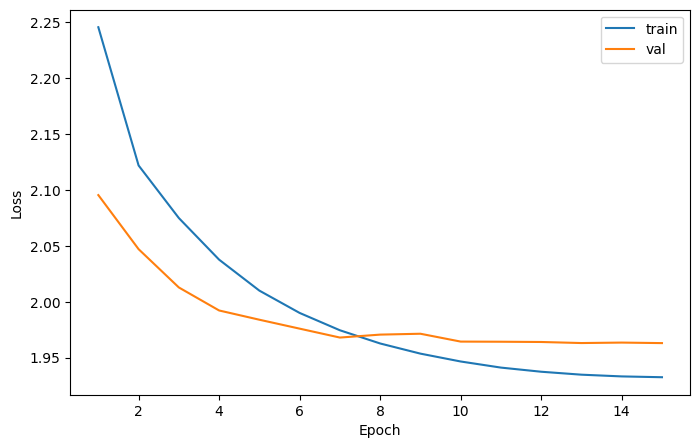

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

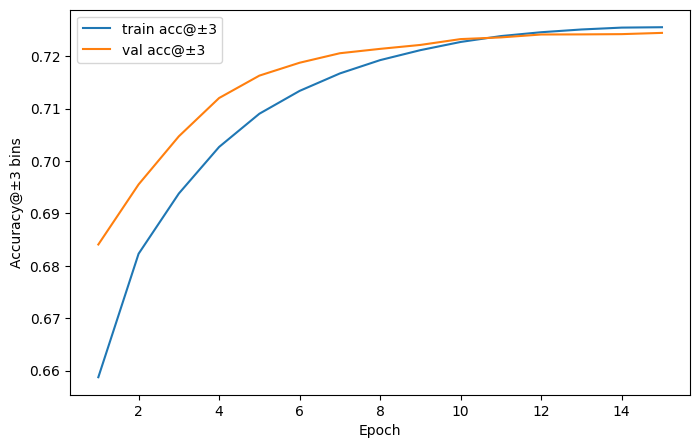

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc_pm3"], label="train acc@±3")
plt.plot(history_df["epoch"], history_df["val_acc_pm3"], label="val acc@±3")
plt.xlabel("Epoch")
plt.ylabel("Accuracy@±3 bins")
plt.legend()
plt.show()